# Run and Evaluate the CN3S Model

In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import pandas as pd

from cn3s import CN3S, CN3SParams

In [32]:
from sklearn.metrics import r2_score

## Select Basin

In [3]:
BASIN = "BarraDosBugres"
STATION = 66010000
BASE_FOLDER = "/data/CN3S/basins/"

path = Path(BASE_FOLDER) / BASIN
assert path.exists(), f"Path {path} does not exist"

## Load Data

In [25]:
prec = pd.read_parquet(path/f"Daily_Prec_{STATION}.parquet")
prec.index = prec.index - pd.Timedelta(hours=12)
prec

,prec
time,
2000-01-01,4.962662
2000-01-02,4.615260
2000-01-03,3.587662
2000-01-04,0.001623
2000-01-05,0.389610
...,...
2026-06-11,0.000000
2026-06-12,0.006494
2026-06-13,0.000000


In [7]:
q = pd.read_parquet(path/f"Daily_Q_{STATION}.parquet")
q

,EstacaoCodigo,NivelConsistencia,Vazao
Data,,,
1966-01-02,66010000,2,104.26
1966-01-03,66010000,2,107.81
1966-01-04,66010000,2,108.53
1966-01-05,66010000,2,107.81
1966-01-06,66010000,2,99.31
...,...,...,...
2025-12-27,66010000,1,125.14
2025-12-28,66010000,1,115.80
2025-12-29,66010000,1,112.90


## Create MODEL

In [8]:
params = CN3SParams()
model = CN3S(params)

In [9]:
params

CN3SParams(area=34334.0, r0=350.0, cn_i=7.35, alfa=0.2, beta=0.00211662329536844, k0=1.0, k1=0.316, k2=0.305)

In [10]:
model.run(prec["prec"].to_list())

Running CN3S model:   0%|          | 0/9659 [00:00<?, ?step/s]

In [16]:
model.results.head()

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s
0,0.001623,"[3.5876622200012207, 4.615259647369385, 4.9626...",1.03,7.359826,3197.17,0.0,350.0,106.75,243.25,106.75,1414.03
1,0.38961,"[0.001623376621864736, 3.5876622200012207, 4.6...",1.02,7.259946,3244.65,0.0,243.37,74.23,169.14,74.23,983.26
2,0.724026,"[0.3896103799343109, 0.001623376621864736, 3.5...",1.01,7.160458,3293.26,0.0,169.37,51.66,117.71,51.66,684.3
3,6.633117,"[0.7240259647369385, 0.3896103799343109, 0.001...",1.0,7.061363,3343.04,0.0,119.81,36.54,83.27,36.54,484.01
4,3.660714,"[6.633116722106934, 0.7240259647369385, 0.3896...",1.02,7.259946,3244.65,0.0,84.43,25.75,58.68,25.75,341.09


## Evaluate Results

In [29]:
results = model.results.copy()
results.index = prec.index[3:]

results = pd.concat([results, q], axis=1)
results = results.dropna()
results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,EstacaoCodigo,NivelConsistencia,Vazao
2000-01-04,0.001623,"[3.5876622200012207, 4.615259647369385, 4.9626...",1.03,7.359826,3197.17,0.0,350.0,106.75,243.25,106.75,1414.03,66010000.0,2.0,101.48
2000-01-05,0.38961,"[0.001623376621864736, 3.5876622200012207, 4.6...",1.02,7.259946,3244.65,0.0,243.37,74.23,169.14,74.23,983.26,66010000.0,2.0,88.84
2000-01-06,0.724026,"[0.3896103799343109, 0.001623376621864736, 3.5...",1.01,7.160458,3293.26,0.0,169.37,51.66,117.71,51.66,684.3,66010000.0,2.0,69.90
2000-01-07,6.633117,"[0.7240259647369385, 0.3896103799343109, 0.001...",1.0,7.061363,3343.04,0.0,119.81,36.54,83.27,36.54,484.01,66010000.0,2.0,67.17
2000-01-08,3.660714,"[6.633116722106934, 0.7240259647369385, 0.3896...",1.02,7.259946,3244.65,0.0,84.43,25.75,58.68,25.75,341.09,66010000.0,2.0,109.21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-27,8.561688,"[1.829545497894287, 0.04707792028784752, 7.733...",1.02,7.259946,3244.65,0.0,7.67,2.34,5.33,2.34,31.0,66010000.0,1.0,125.14
2025-12-28,1.498377,"[8.561688423156738, 1.829545497894287, 0.04707...",1.02,7.259946,3244.65,0.0,5.8,1.77,4.03,1.77,23.45,66010000.0,1.0,115.80
2025-12-29,3.35552,"[1.4983766078948975, 8.561688423156738, 1.8295...",1.03,7.359826,3197.17,0.0,5.09,1.55,3.54,1.55,20.53,66010000.0,1.0,112.90
2025-12-30,6.820617,"[3.3555195331573486, 1.4983766078948975, 8.561...",1.03,7.359826,3197.17,0.0,5.7,1.74,3.96,1.74,23.05,66010000.0,1.0,107.13


<Axes: title={'center': 'Model Results vs Observed Discharge'}>

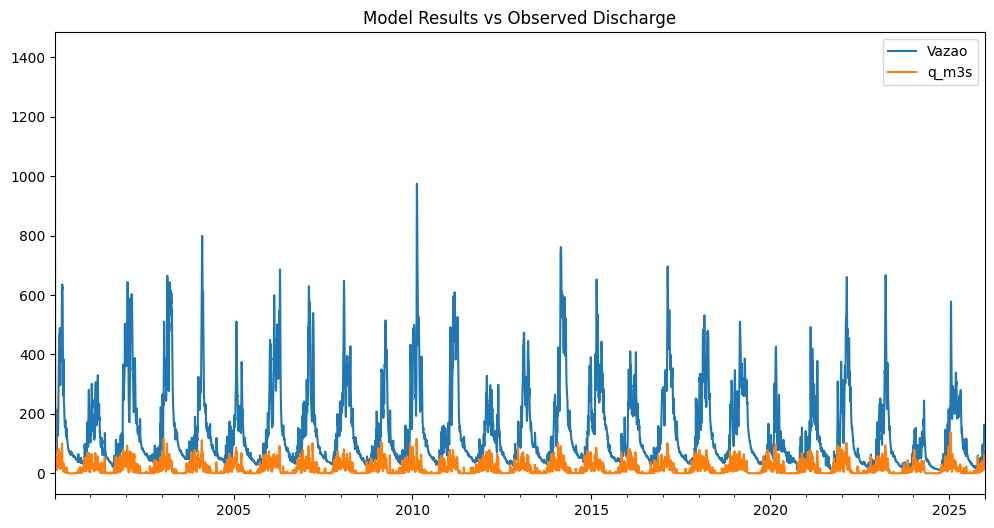

In [30]:
results.plot(y=["Vazao", "q_m3s"], figsize=(12, 6), title="Model Results vs Observed Discharge")

In [33]:
r2_score(results["Vazao"], results["q_m3s"])

-0.7509780352225082

In [13]:
r2_score(results["Vazao"], [results["Vazao"].mean()] * len(results))

0.0

## Calibration

In [ ]:
import numpy as np
from scipy.optimize import differential_evolution

# Create the model with default params
model = CN3S(CN3SParams())


def objective(params: np.ndarray, area: float) -> float:
    """
    Objective function: Minimize NSE (r2_score) between model results and observed discharge.

    Args:
    params (CN3SParams): Model parameters to optimize.
    area (float): Area of the catchment.

    Returns:
    float: Negative NSE (r2_score) between model results and observed discharge.

    """
    cn3s_params = CN3SParams.from_vector(params, area=area)

    # Update the model's params
    model.params = cn3s_params
    model.run(monthly_prec["prec"].to_list(), pbar=False)

    results = model.results.copy()
    results.index = monthly_prec.index[3:]
    results = pd.concat([results, monthly_q], axis=1)
    results = results.dropna()

    return -r2_score(results["Vazao"], results["q_m3s"])

In [32]:
params = np.array(CN3SParams().as_list())
objective(params, area=34334)

9.495631401695881

In [16]:
def callback(x, convergence):
    print(f"Current parameters: {x}, convergence: {convergence}")
    print(x.x)
    print(x.fun)

In [34]:
# Parameter bounds: (min, max) for each of r0, cn_i, alfa, beta, k0, k1, k2
bounds = [
    (50.0, 1000.0),  # r0:   initial groundwater storage (mm)
    (1.0, 30.0),  # cn_i: Curve Number anchor
    (0.05, 0.5),  # alfa: initial abstraction ratio
    (1e-4, 0.02),  # beta: antecedent precipitation sensitivity
    (0.1, 2.0),  # k0:   exponential decay factor
    (0.01, 0.99),  # k1:   groundwater recharge fraction
    (0.01, 0.99),  # k2:   baseflow recession coefficient
]

result = differential_evolution(
    func=objective,
    bounds=bounds,
    args=(34334,),  # pass area as an argument to the objective function
    seed=42,
    maxiter=50,
    tol=1e-2,
    workers=-1,  # parallel evaluation using all CPU cores
    disp=True,
    # callback=callback,
)
result

differential_evolution step 1: f(x)= -0.22894295673872844
differential_evolution step 2: f(x)= -0.7178890579095496
differential_evolution step 3: f(x)= -0.7226364124716377
differential_evolution step 4: f(x)= -0.7226364124716377
differential_evolution step 5: f(x)= -0.7314943108862569
differential_evolution step 6: f(x)= -0.7314943108862569
differential_evolution step 7: f(x)= -0.7314943108862569
differential_evolution step 8: f(x)= -0.7314943108862569
differential_evolution step 9: f(x)= -0.7314943108862569
differential_evolution step 10: f(x)= -0.7314943108862569
differential_evolution step 11: f(x)= -0.755570172925947
differential_evolution step 12: f(x)= -0.7584793251116073
differential_evolution step 13: f(x)= -0.7643407149188729
differential_evolution step 14: f(x)= -0.7643407149188729
differential_evolution step 15: f(x)= -0.7644866702791923
differential_evolution step 16: f(x)= -0.7644866702791923
differential_evolution step 17: f(x)= -0.7644866702791923
differential_evolution 

Process ForkPoolWorker-17:
Process ForkPoolWorker-18:
Process ForkPoolWorker-15:
Process ForkPoolWorker-13:
Process ForkPoolWorker-16:
Process ForkPoolWorker-14:


KeyboardInterrupt: 

In [28]:
params = CN3SParams().from_vector(result.x, 9642)
objective(params.as_list(), area=params.area)

-0.7678181341590388

In [ ]:
params.k1 = 0.1
objective(params.as_list(), area=params.area)

-0.11156998527312378

In [19]:
cn3s_params = CN3SParams(
    area=9600,
    r0=result.x[0],
    cn_i=result.x[1],
    alfa=result.x[2],
    beta=result.x[3],
    k0=result.x[4],
    k1=result.x[5],
    k2=result.x[6],
)

model = CN3S(cn3s_params)
model.run(monthly_prec["prec"].to_list())


Running CN3S model:   0%|          | 0/313 [00:00<?, ?step/s]

In [20]:
model.results.index = monthly_prec.index[3:]
model.results = pd.concat([model.results, monthly_q], axis=1)
model.results = model.results.dropna()
model.results

,prec,past_prec,vj,cnv,s,q_up,r1,q_low,r,q_mm,q_m3s,EstacaoCodigo,NivelConsistencia,Vazao
2000-04-01,86.9,"[282.9, 292.1, 159.9]",3.0,33.501452,504.18,0.0,120.86,58.3,62.56,58.3,215.93,66010000.0,2.0,191.1
2000-05-01,12.0,"[86.9, 282.9, 292.1]",2.92,32.272483,533.05,0.0,66.27,31.97,34.3,31.97,118.41,66010000.0,2.0,97.2
2000-06-01,0.0,"[12.0, 86.9, 282.9]",2.01,19.256126,1065.06,0.0,34.3,16.55,17.75,16.55,61.3,66010000.0,2.0,67.7
2000-07-01,0.6,"[0.0, 12.0, 86.9]",1.25,9.984523,2289.94,0.0,17.94,8.65,9.29,8.65,32.04,66010000.0,2.0,57.4
2000-08-01,12.5,"[0.6, 0.0, 12.0]",1.03,7.639692,3070.74,0.0,13.16,6.35,6.81,6.35,23.52,66010000.0,2.0,45.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-01,4.8,"[0.3, 18.8, 22.8]",1.12,8.577907,2707.1,0.0,10.09,4.87,5.22,4.87,18.04,66010000.0,1.0,31.9
2025-09-01,16.0,"[4.8, 0.3, 18.8]",1.07,8.05296,2900.12,0.0,10.17,4.91,5.26,4.91,18.19,66010000.0,1.0,21.8
2025-10-01,80.1,"[16.0, 4.8, 0.3]",1.08,8.157214,2859.81,0.0,30.03,14.49,15.54,14.49,53.67,66010000.0,1.0,26.0
2025-11-01,88.7,"[80.1, 16.0, 4.8]",1.36,11.219561,2009.9,0.0,42.97,20.73,22.24,20.73,76.78,66010000.0,1.0,35.9


In [21]:
result.x[0]

93.98919578626965

<Axes: title={'center': 'Optimized Model Results vs Observed Discharge'}>

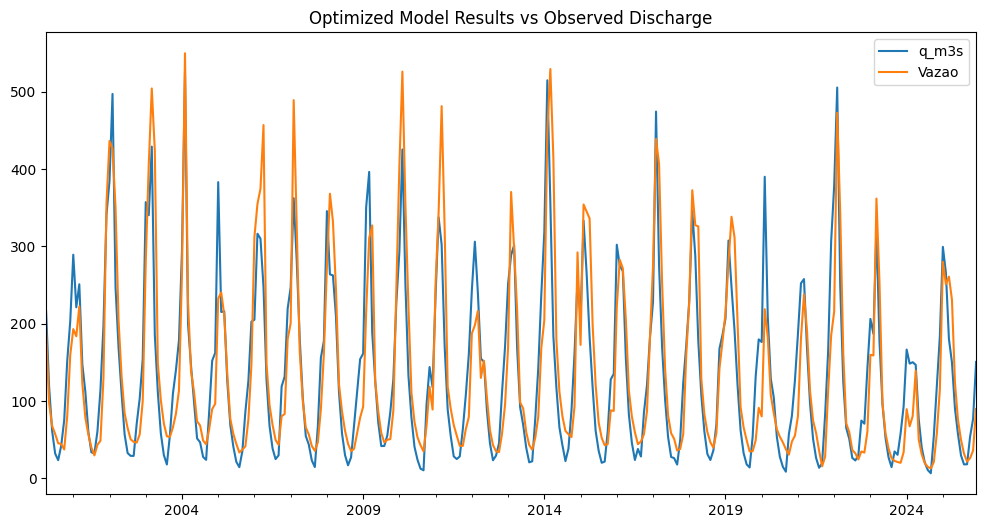

In [22]:
model.results.plot(
    y=["q_m3s", "Vazao"], figsize=(12, 6), title="Optimized Model Results vs Observed Discharge"
)

In [23]:
r2_score(model.results["Vazao"], model.results["q_m3s"])

0.7679906838542723

In [24]:
r0_opt, cn_i_opt, alfa_opt, beta_opt, k0_opt, k1_opt, k2_opt = result.x

best_params = CN3SParams(
    area=params.area,
    r0=r0_opt,
    cn_i=cn_i_opt,
    alfa=alfa_opt,
    beta=beta_opt,
    k0=k0_opt,
    k1=k1_opt,
    k2=k2_opt,
)
best_model = CN3S(best_params)
best_model.run(prec_list.copy())

best_results = best_model.results.copy()
best_results.index = monthly_prec.index[3:]
best_results = pd.concat([best_results, monthly_q], axis=1).dropna()

print(f"Calibrated NSE: {nse(best_results['q_m3s'].values, best_results['Vazao'].values):.4f}")
best_params

AttributeError: 'numpy.ndarray' object has no attribute 'area'

In [ ]:
best_results.plot(
    y=["Vazao", "q_m3s"], figsize=(12, 6), title="Calibrated Model vs Observed Discharge"
)